# CSMODEL MP Phase 1

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Importing

In [2]:
# Defining data for the dataframe
LFS_df = pd.read_csv('LFSPUFApril2016.CSV', dtype=pd.StringDtype())
LFS_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180862 entries, 0 to 180861
Data columns (total 50 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   PUFREG           180862 non-null  string
 1   PUFPRV           180862 non-null  string
 2   PUFPRRCD         180862 non-null  string
 3   PUFHHNUM         180862 non-null  string
 4   PUFURB2K10       180862 non-null  string
 5   PUFPWGTFIN       180862 non-null  string
 6   PUFSVYMO         180862 non-null  string
 7   PUFSVYYR         180862 non-null  string
 8   PUFPSU           180862 non-null  string
 9   PUFRPL           180862 non-null  string
 10  PUFHHSIZE        180862 non-null  string
 11  PUFC01_LNO       180862 non-null  string
 12  PUFC03_REL       180862 non-null  string
 13  PUFC04_SEX       180862 non-null  string
 14  PUFC05_AGE       180862 non-null  string
 15  PUFC06_MSTAT     180862 non-null  string
 16  PUFC07_GRADE     180862 non-null  string
 17  PUFC08_CUR

# Dataset Description

# Data Cleaning

In [3]:

# PUFC05_AGE
LFS_df['PUFC05_AGE'] = LFS_df['PUFC05_AGE'].astype(int)
LFS_df = LFS_df[LFS_df['PUFC05_AGE'] >= 15]

# PUFC10_CONWR_VS1
LFS_df['PUFC10_CONWR'] = LFS_df['PUFC10_CONWR'].replace({
        # ' ':'Below Working Age', <-- not needed
        '1':'OCW',
        '2':'not OCW worker',
        '3':'diplomatic',
        '4':'student or tourist',
        '5':'other'
})

# PUFC14_PROCC_VS2
LFS_df['PUFC14_PROCC'] = LFS_df['PUFC14_PROCC'].replace({
        '  ' :  'None',
        '01' :	'Armed Forces Occupations',
        '02' :	'Armed Forces Occupations',
        '03' :	'Armed Forces Occupations',
        '11' :	'Managers',
        '12' :	'Managers',
        '13' :	'Managers',
        '14' :	'Managers',
        '21' :	'Professionals',
        '22' :	'Professionals',
        '23' :	'Professionals',
        '24' :	'Professionals',
        '25' :	'Professionals',
        '26' :	'Professionals',
        '31' :	'Technicians and Associate Professionals',
        '32' :	'Technicians and Associate Professionals',
        '33' :	'Technicians and Associate Professionals',
        '34' :	'Technicians and Associate Professionals',
        '35' :	'Technicians and Associate Professionals',
        '41' :	'Clerical Support Workers',
        '42' :	'Clerical Support Workers',
        '43' :  'Clerical Support Workers',
        '44' :	'Clerical Support Workers',
        '51' :	'Service and Sales Workers',
        '52' :	'Service and Sales Workers',
        '53' :	'Service and Sales Workers',
        '54' :	'Service and Sales Workers',
        '61' :	'Skilled Agricultural, Forestry and Fishery Workers',
        '62' :	'Skilled Agricultural, Forestry and Fishery Workers',
        '63' :	'Skilled Agricultural, Forestry and Fishery Workers',
        '71' :	'Craft and Related Trades Workers',
        '72' :	'Craft and Related Trades Workers',
        '73' :	'Craft and Related Trades Workers',
        '74' :	'Craft and Related Trades Workers',
        '75' :	'Craft and Related Trades Workers',
        '81' :	'Plant and Machine Operators and Assemblers',
        '82' :	'Plant and Machine Operators and Assemblers',
        '83' :	'Plant and Machine Operators and Assemblers',
        '91' :	'Elementary Occupations',
        '92' :	'Elementary Occupations',
        '93' :	'Elementary Occupations',
        '94' :	'Elementary Occupations',
        '95' :	'Elementary Occupations',
        '96' :	'Elementary Occupations',
})

# PUFC16_PKB_VS2
indu_list = [str(x) for x in range(10, 44)]
serv_list = [str(x) for x in range(45, 100)]
LFS_df['PUFC16_PKB'] = LFS_df['PUFC16_PKB'].replace(indu_list, "Industry")
LFS_df['PUFC16_PKB'] = LFS_df['PUFC16_PKB'].replace(serv_list, "Services")
LFS_df['PUFC16_PKB'] = LFS_df['PUFC16_PKB'].replace({
        '  ':'None',
        '01' : 'Agriculture',
        '02' : 'Agriculture'	,
        '03' : 'Agriculture'	,
        '05' : 'Industry'	,
        '06' : 'Industry'	,
        '07' : 'Industry'	,
        '08' : 'Industry'	,
        '09' : 'Industry'	,
                                                     })

LFS_df['PUFC10_CONWR'].unique()
LFS_df['PUFC14_PROCC'].unique()
LFS_df['PUFC16_PKB'].unique()
LFS_df.groupby('PUFC05_AGE')['PUFC25_PBASIC'].value_counts()
LFS_df['PUFC16_PKB'].info()

<class 'pandas.core.series.Series'>
Index: 123080 entries, 0 to 180861
Series name: PUFC16_PKB
Non-Null Count   Dtype 
--------------   ----- 
123080 non-null  string
dtypes: string(1)
memory usage: 1.9 MB


### Cleaning educational-background columns

In [4]:
LFS_df['PUFC07_GRADE']

0         350
1         350
2         350
3         320
4         350
         ... 
180850    000
180851    000
180857    350
180858    830
180861    350
Name: PUFC07_GRADE, Length: 123080, dtype: string

In [5]:
LFS_df['PUFC07_GRADE'].str.isspace().sum() # no spaces

np.int64(0)

In [6]:
(LFS_df['PUFC07_GRADE'].isna() == 1).sum() # no null values

np.int64(0)

In [7]:
LFS_df['PUFC07_GRADE'] = LFS_df['PUFC07_GRADE'].astype('object')

elementary = ['210','220','230','240','250','260'] # correct
highschool = ['310','320','330','340'] # correct
post_secondary = ['410','420']
post_secondary_grads = ['501', '508', '509', '514', '521', '522', '531', '532', '534', '542', 
               '544', '548', '552', '554', '558', '562', '564', '572', '576', '581', 
               '584', '585', '586', '589']
college = ['810','820','830','840'] # correct
college_graduate = ["601", "614", "621", "622", "631", "632", "634", "638",
    "642", "644", "646", "648", "652", "654", "658", "662",
    "664", "672", "676", "681", "684", "685", "686", "689"]

single_map = {
    '000': 0, # correct
    '010': 1, # correct
    '280': 3, # correct
    '350': 5, # correct
    '900': 10 # correct
}
LFS_df['PUFC07_GRADE'] = LFS_df['PUFC07_GRADE'].replace(single_map)

LFS_df.loc[LFS_df['PUFC07_GRADE'].isin(elementary),             'PUFC07_GRADE'] = 2
LFS_df.loc[LFS_df['PUFC07_GRADE'].isin(highschool),             'PUFC07_GRADE'] = 4
LFS_df.loc[LFS_df['PUFC07_GRADE'].isin(post_secondary),         'PUFC07_GRADE'] = 6
LFS_df.loc[LFS_df['PUFC07_GRADE'].isin(post_secondary_grads),   'PUFC07_GRADE'] = 7
LFS_df.loc[LFS_df['PUFC07_GRADE'].isin(college),                'PUFC07_GRADE'] = 8
LFS_df.loc[LFS_df['PUFC07_GRADE'].isin(college_graduate),       'PUFC07_GRADE'] = 9

In [8]:
unique_gradecompleted = LFS_df['PUFC07_GRADE'].unique()
unique_gradecompleted

array([5, 4, 9, 2, 3, 10, 8, 7, 0, 6, 1], dtype=object)

In [9]:
LFS_df['PUFC09_GRADTECH']

0         2
1         2
2         2
3         2
4         2
         ..
180850    2
180851    2
180857    2
180858    2
180861    2
Name: PUFC09_GRADTECH, Length: 123080, dtype: string

In [10]:
LFS_df['PUFC09_GRADTECH'].str.isspace().sum()

np.int64(0)

In [11]:
(LFS_df[(LFS_df['PUFC05_AGE'] < 15) & (LFS_df['PUFC09_GRADTECH'] == ' ')]).shape

(0, 50)

In [12]:
LFS_df['PUFC09_GRADTECH'].unique()

<StringArray>
['2', '1']
Length: 2, dtype: string

In [13]:
LFS_df['PUFC09_GRADTECH'] = LFS_df['PUFC09_GRADTECH'].astype(int)

# Research Question and Exploratory Data Analysis

In [14]:
list(LFS_df.columns)

['PUFREG',
 'PUFPRV',
 'PUFPRRCD',
 'PUFHHNUM',
 'PUFURB2K10',
 'PUFPWGTFIN',
 'PUFSVYMO',
 'PUFSVYYR',
 'PUFPSU',
 'PUFRPL',
 'PUFHHSIZE',
 'PUFC01_LNO',
 'PUFC03_REL',
 'PUFC04_SEX',
 'PUFC05_AGE',
 'PUFC06_MSTAT',
 'PUFC07_GRADE',
 'PUFC08_CURSCH',
 'PUFC09_GRADTECH',
 'PUFC10_CONWR',
 'PUFC11_WORK',
 'PUFC12_JOB',
 'PUFC14_PROCC',
 'PUFC16_PKB',
 'PUFC17_NATEM',
 'PUFC18_PNWHRS',
 'PUFC19_PHOURS',
 'PUFC20_PWMORE',
 'PUFC21_PLADDW',
 'PUFC22_PFWRK',
 'PUFC23_PCLASS',
 'PUFC24_PBASIS',
 'PUFC25_PBASIC',
 'PUFC26_OJOB',
 'PUFC27_NJOBS',
 'PUFC28_THOURS',
 'PUFC29_WWM48H',
 'PUFC30_LOOKW',
 'PUFC31_FLWRK',
 'PUFC32_JOBSM',
 'PUFC33_WEEKS',
 'PUFC34_WYNOT',
 'PUFC35_LTLOOKW',
 'PUFC36_AVAIL',
 'PUFC37_WILLING',
 'PUFC38_PREVJOB',
 'PUFC40_POCC',
 'PUFC41_WQTR',
 'PUFC43_QKB',
 'PUFNEWEMPSTAT']

In [15]:
LFS_df['PUFC14_PROCC'].unique()

<StringArray>
['Skilled Agricultural, Forestry and Fishery Workers',
                             'Elementary Occupations',
                          'Service and Sales Workers',
                                               'None',
                                           'Managers',
                   'Craft and Related Trades Workers',
         'Plant and Machine Operators and Assemblers',
            'Technicians and Associate Professionals',
                           'Clerical Support Workers',
                                      'Professionals',
                           'Armed Forces Occupations']
Length: 11, dtype: string

In [16]:
LFS_df[['PUFC09_GRADTECH', 'PUFC14_PROCC']]

,PUFC09_GRADTECH,PUFC14_PROCC
0,2,"Skilled Agricultural, Forestry and Fishery Wor..."
1,2,Elementary Occupations
2,2,Elementary Occupations
3,2,"Skilled Agricultural, Forestry and Fishery Wor..."
4,2,Elementary Occupations
...,...,...
180850,2,"Skilled Agricultural, Forestry and Fishery Wor..."
180851,2,"Skilled Agricultural, Forestry and Fishery Wor..."
180857,2,Managers
180858,2,None


In [17]:
LFS_df['PUFNEWEMPSTAT'].unique()

<StringArray>
['1', '3', '2', ' ']
Length: 4, dtype: string

In [18]:
LFS_df['PUFNEWEMPSTAT'].str.isspace().sum()

np.int64(3555)

In [19]:
LFS_df = LFS_df[LFS_df['PUFNEWEMPSTAT'] != ' ']
LFS_df['PUFNEWEMPSTAT'].str.isspace().sum()

np.int64(0)

In [20]:
LFS_df['PUFNEWEMPSTAT'] = LFS_df['PUFNEWEMPSTAT'].astype(int)

In [21]:
(LFS_df['PUFNEWEMPSTAT'] == 3).sum()

np.int64(43877)

In [22]:
(LFS_df['PUFNEWEMPSTAT'] != 3).sum()

np.int64(75648)

In [23]:
LFS_df.shape

(119525, 50)

In [24]:
LFS_df = LFS_df[LFS_df['PUFNEWEMPSTAT'] != 3]

In [25]:
LFS_df.shape

(75648, 50)

In [26]:
LFS_df['PUFNEWEMPSTAT'].unique()

array([1, 2])

In [27]:
(LFS_df['PUFNEWEMPSTAT'] == 2).sum()

np.int64(4293)

In [28]:
LFS_df[(LFS_df['PUFNEWEMPSTAT'] == 2) & (LFS_df['PUFC14_PROCC'] == 'None')].shape

(4293, 50)

In [29]:
LFS_df[(LFS_df['PUFNEWEMPSTAT'] == 2) & (LFS_df['PUFC14_PROCC'] != 'None')].shape

(0, 50)

In [30]:
LFS_df[(LFS_df['PUFNEWEMPSTAT'] == 2)].shape

(4293, 50)

In [31]:
LFS_df = LFS_df[LFS_df['PUFNEWEMPSTAT'] != 2]

In [41]:
table = pd.crosstab(
    LFS_df["PUFC14_PROCC"],
    LFS_df["PUFC09_GRADTECH"],
    margins=True,
    margins_name="Total"
)
table

PUFC09_GRADTECH,1,2,Total
PUFC14_PROCC,,,
Armed Forces Occupations,21,152,173
Clerical Support Workers,215,3413,3628
Craft and Related Trades Workers,574,4872,5446
Elementary Occupations,614,18434,19048
Managers,768,11277,12045
Plant and Machine Operators and Assemblers,326,3500,3826
Professionals,133,3538,3671
Service and Sales Workers,750,9799,10549
"Skilled Agricultural, Forestry and Fishery Workers",286,10202,10488


In [47]:
LFS_df["attended_num"] 

0         0
1         0
2         0
3         0
4         0
         ..
180848    0
180850    0
180851    0
180857    0
180861    0
Name: attended_num, Length: 71355, dtype: int64

In [46]:
# map 1/2 → 1/0 so that “mean” becomes the proportion saying “Yes”
LFS_df["attended_num"] = (LFS_df["PUFC09_GRADTECH"] == 1).astype(int)

summary_flag = (
    LFS_df
    .groupby("PUFC14_PROCC")["attended_num"]
    .agg([
        ("proportion_yes", "mean"),    # mean of 0/1
        ("mode_flag", lambda x: x.mode().iat[0]),      
        ("count", "count")
    ])
)
print(summary_flag)

                                                    proportion_yes  mode_flag  \
PUFC14_PROCC                                                                    
Armed Forces Occupations                                  0.121387          0   
Clerical Support Workers                                  0.059261          0   
Craft and Related Trades Workers                          0.105398          0   
Elementary Occupations                                    0.032234          0   
Managers                                                  0.063761          0   
Plant and Machine Operators and Assemblers                0.085206          0   
Professionals                                             0.036230          0   
Service and Sales Workers                                 0.071097          0   
Skilled Agricultural, Forestry and Fishery Workers        0.027269          0   
Technicians and Associate Professionals                   0.098347          0   

                           

In [49]:
desc = (
    LFS_df
    .groupby("PUFC14_PROCC")["PUFC09_GRADTECH"]
    .describe()   # gives count, mean, std, min, 25%, 50%, 75%, max
)
print(desc)

                                                      count      mean  \
PUFC14_PROCC                                                            
Armed Forces Occupations                              173.0  1.878613   
Clerical Support Workers                             3628.0  1.940739   
Craft and Related Trades Workers                     5446.0  1.894602   
Elementary Occupations                              19048.0  1.967766   
Managers                                            12045.0  1.936239   
Plant and Machine Operators and Assemblers           3826.0  1.914794   
Professionals                                        3671.0  1.963770   
Service and Sales Workers                           10549.0  1.928903   
Skilled Agricultural, Forestry and Fishery Workers  10488.0  1.972731   
Technicians and Associate Professionals              2481.0  1.901653   

                                                         std  min  25%  50%  \
PUFC14_PROCC                                

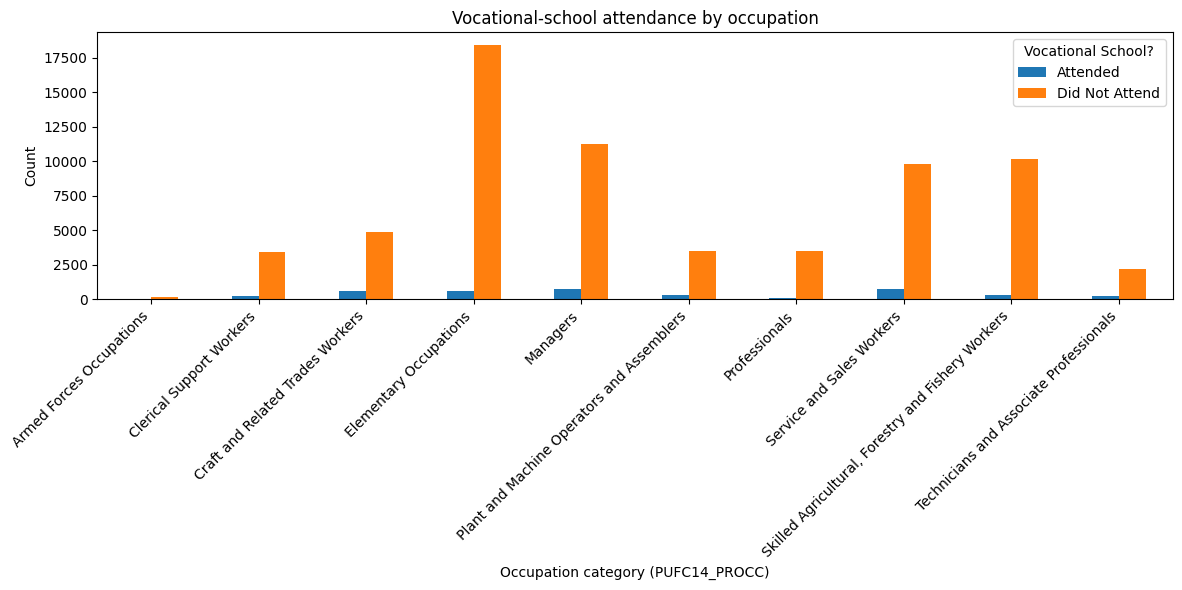

In [33]:
import matplotlib.pyplot as plt

# 1) aggregate counts
counts = (
    LFS_df
    .groupby(["PUFC14_PROCC", "PUFC09_GRADTECH"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={1: "Attended", 2: "Did Not Attend"})
)

# 2) plot grouped bar chart
ax = counts.plot(
    kind="bar",
    figsize=(12, 6),
)
ax.set_xlabel("Occupation category (PUFC14_PROCC)")
ax.set_ylabel("Count")
ax.set_title("Vocational-school attendance by occupation")
ax.legend(title="Vocational School?")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [34]:
LFS_df["PUFC18_PNWHRS"] = LFS_df["PUFC18_PNWHRS"].astype(int)

In [35]:
LFS_df[(LFS_df["PUFC09_GRADTECH"] == 1) & ( LFS_df["PUFC18_PNWHRS"] == 8)].shape[0]

2193

In [36]:
(LFS_df["PUFC09_GRADTECH"] == 1).sum()

np.int64(3931)

In [37]:
LFS_df[(LFS_df["PUFC09_GRADTECH"] == 2) & ( LFS_df["PUFC18_PNWHRS"] != 8)].shape[0]

34082

In [38]:
LFS_df[(LFS_df["PUFC09_GRADTECH"] == 1) & ( LFS_df["PUFC18_PNWHRS"] != 8)].describe()

,PUFC05_AGE,PUFC09_GRADTECH,PUFC18_PNWHRS,PUFNEWEMPSTAT
count,1738.000000,1738.0,1738.000000,1738.0
mean,39.971807,1.0,7.396433,1.0
std,13.612949,0.0,3.741493,0.0
min,16.000000,1.0,1.000000,1.0
25%,28.250000,1.0,4.000000,1.0
50%,39.000000,1.0,6.000000,1.0
75%,50.000000,1.0,10.000000,1.0
max,82.000000,1.0,16.000000,1.0


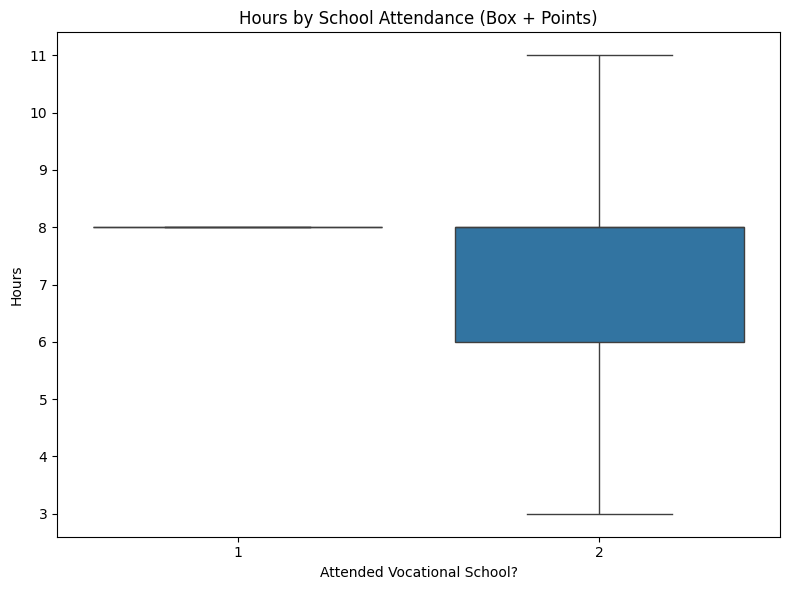

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.boxplot(
    data=LFS_df,
    x="PUFC09_GRADTECH",
    y="PUFC18_PNWHRS",
    showfliers=False,    # hide extreme point markers
)

plt.xlabel("Attended Vocational School?")
plt.ylabel("Hours")
plt.title("Hours by School Attendance (Box + Points)")
plt.tight_layout()
plt.show()
